# φ⁴ Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{raw} = H_0 + \frac{g}{24 \cdot r \cdot 8\pi}\,\delta H_4$$

$$H_\text{LO} = H_0 + \frac{1}{4} m_2^2 \,\delta H_2 + \frac{g+\lambda_2}{24 \cdot r \cdot 8\pi}\,\delta H_4$$

and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941


In [5]:
import math

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sp_linalg
from scipy.special import factorial
from scipy.sparse import identity


import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from collections import Counter
import time
import csv


%matplotlib inline

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [6]:
def omega(l, m, r):
    """State Frequency"""
    return math.sqrt(float(l)*float(l)/(r*r) + m*m)


## 2. Basis generation via the change problem

The change problem is essentially how many ways can you make change for some quantity given a set of coins. Here we have any angular momentum state.

`gen_coins` builds a dictionary with all of the ways to create a number by summing smaller numbers. This is stored in the global state `coins` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `coins` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`coin_dict` then turns the global dictionary `coins` into a global frequency dictionary `coinDict`. Elements of `coinDict` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`coin_energies` computes a list of energies for each set of coins labelled by `l` in `coins`. As positive and negative `l` states have the same energy, this only needs computing once.



In [7]:
def coin_dict(coins):
    #Turns above into a counting dictionary
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(val) for val in coins[key]]
        
def gen_coins(n_max):
    global coins
    #Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    #If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        coins[i] = sorted(coins[i], key=len) #Not sure this helps?
        
    coin_dict(coins)
    return coins


def coin_energies(l,m,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, m, r), change)) for change in coins[l]]
    
            

In [11]:
#Example of the coins 
gen_coins(4)
for i in range(3,5):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `coinDicts` together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

In [5]:
def gen_basis(lmax, e_max, m, r):
    result = []
    #l=0:
    result += [{0: i} for i in range(0, int(math.floor(e_max/m)) + 1)]    
    #l>0:
    for l in range(1,lmax+1):
        gen_coins(l) #All ways of making up to lmax with smaller numbers
        coin_dict()
        coinEnergies = coin_energies(l,m,r)

        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                #Build a temporary energy for the state
                e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                if e_temp > 0: #Fill up l=0 state up to e_max.
                    cicjDict = {-jjj:cjj for jjj,cjj in cj.items()} | ci 
                    result += [cicjDict]
                    result += [{0: i} | cicjDict for i in range(1, int(math.floor(e_temp/m)) + 1)]
                
    return result

In [12]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, m, r):
    if m**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - m**2))))))
    return 0

## 3. Timing Between Old Method and New Method

E_max: 6 | Time: 0.002457 seconds
E_max: 7 | Time: 0.000248 seconds
E_max: 8 | Time: 0.000252 seconds
E_max: 9 | Time: 0.000239 seconds
E_max: 10 | Time: 0.000366 seconds
E_max: 11 | Time: 0.000688 seconds
E_max: 12 | Time: 0.000948 seconds
E_max: 13 | Time: 0.006333 seconds
E_max: 14 | Time: 0.002451 seconds
E_max: 15 | Time: 0.003460 seconds
E_max: 16 | Time: 0.005399 seconds
E_max: 17 | Time: 0.008232 seconds
E_max: 18 | Time: 0.011919 seconds
E_max: 19 | Time: 0.017801 seconds


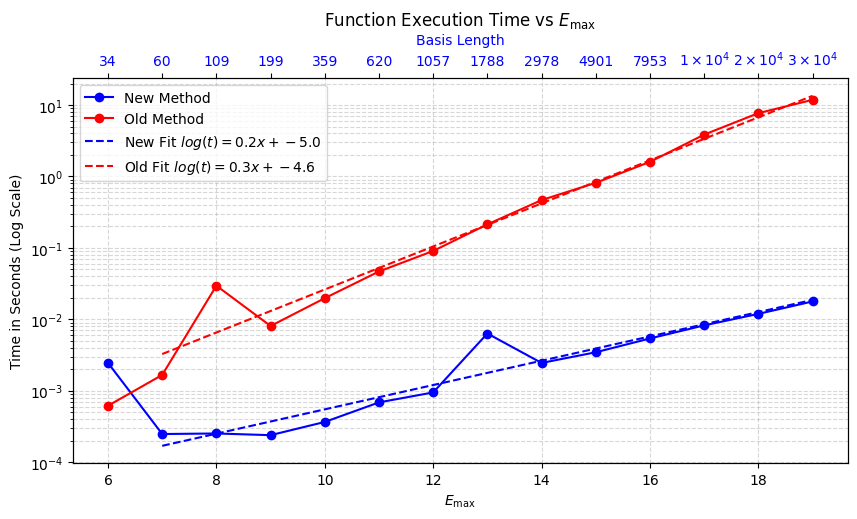

In [8]:
m = 1; r = 10/(2*math.pi)
execution_times = []; len_basis = []

emax_list = range(6,20) #Test Range of E_max.

# 1. Iterate over emax_list
for emax in emax_list:
    start_time = time.perf_counter()
    lmaxeff = effective_lmax(emax,emax,m,r)
    # Generating the basis via the above method.
    basis = gen_basis(lmaxeff,emax,m,r)
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    execution_times.append(duration)
    len_basis.append(len(basis))
    
    del coins #For fairness, reset the coins dictionary each time.
    
    print(f"E_max: {emax} | Time: {duration:.6f} seconds")

# 2. Importing comparison timings. This file is produced from the old code and imported here.
csv_filename = "benchmark_results.csv"
execution_times_old = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader) #Skips Header.
    for row in reader:
        execution_times_old.append(float(row[1])) # Convert time back to float


# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='New Method')
ax1.plot(emax_list, execution_times_old, marker ='o', linestyle='-', color='r', label='Old Method')

# 4. First degree polynomial fit to the timing data.
coef_new = (np.polyfit(emax_list[1:], np.log10(execution_times)[1:], 1))
coef_old = (np.polyfit(emax_list[1:], np.log10(execution_times_old)[1:], 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', label=f'New Fit $log(t)={coef_new[0]:.1f}x+{coef_new[1]:.1f}$')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', label=f'Old Fit $log(t)={coef_old[0]:.1f}x+{coef_old[1]:.1f}$')
ax1.legend()

# --- A second x-axis to show the basis length. 
ax2 = ax1.twiny() 
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(emax_list) 

formatted_top_labels = []
for x in len_basis:
    if x>10000:#Cleaning up long numbers into standard form.
        base, exponent = f"{x:.0e}".split("e")
        # Clean up the sign on the exponent (e.g., +06 becomes 6)
        exponent = int(exponent) 
        # Wrap in LaTeX math style for superscripts
        formatted_top_labels.append(f"${base} \\times 10^{{{exponent}}}$")
    else:
        formatted_top_labels.append(x)
    
ax2.set_xticklabels(formatted_top_labels) 
ax2.set_xlabel('Basis Length', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')


plt.title(r'Function Execution Time vs $E_\text{max}$')
plt.show()


## 3. State Occupation Plot

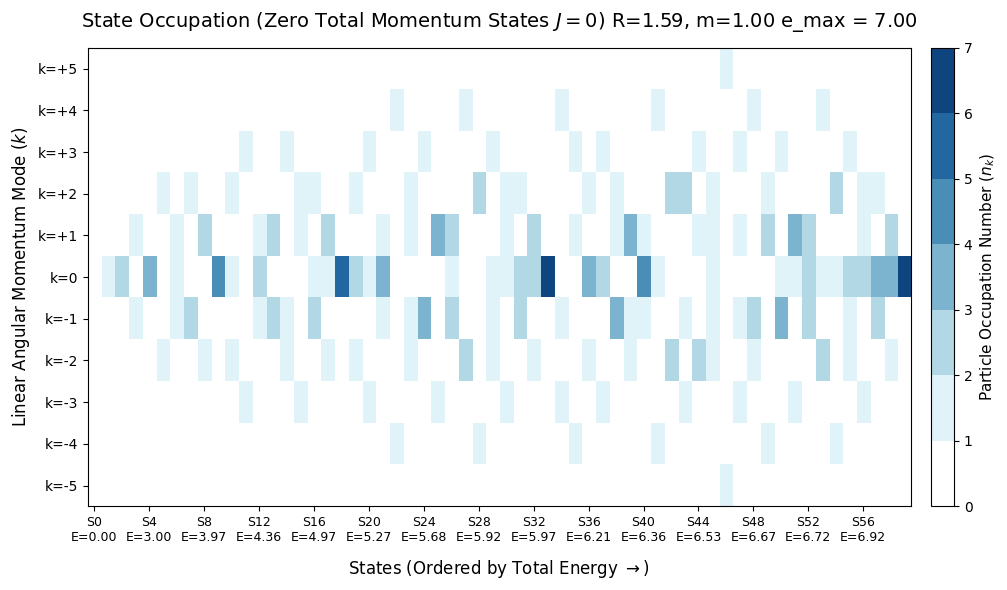

In [9]:
m = 1; r = 10/(2*math.pi); e_max=7; lmaxeff = effective_lmax(e_max,e_max,m,r)
basis = gen_basis(lmaxeff,e_max,m,r)

# -- Mode Range and J=0 Basis for Plot ---

lrange = lmaxeff
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))


# --- Sort states by energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []

# Computing the energies
state_energies = []
for state in _basis:
    state_energies.append(sum([nl*omega(l, m, r) for l, nl in state.items()]))

# Sorting the states
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Grid of Angular Momenta on the y-axis with States of Increasing Energies on x-axis ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes]
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]

ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
ax.set_xticklabels(_state_labels, fontsize=9)
ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={m:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

## 4. Raising and lowering operators.
The following functions take two states, ordered in energy, and computes matrix element for their transition amplitude. 

- `lower4` — annihilate 4 particles
- `raise1low3` — annihilate 3, create 1
- `raise2low2` — annihilate 2, create 2


The correct symmetry factor is computed following arXiv:2507.15941 Eqs. (2.5)–(2.7).

In [297]:
def lower4(stA, stB): 
    #Lowers state A to state B.
    # --- Create a dictionary of the 'difference' between state A and state B.
    diff = stA.copy() 
    for j in stB.keys():
        if j in stA.keys():
            diff[j] = (stA[j] - stB[j])
            
            if diff[j]<0: #No way of making state B without creation operators.
                return 0 
        
        elif stB[j]>0: #No way of making state B without creation operators.
            return 0
        
    # --- The 'Hamming distance' between state A and state B.
    if len(diff)>0:
        hammDist = sum(diff.values())
        if hammDist!=4: #Hamming Distance Must Be 4.
            return 0
        
    # --- Calculating the normalisation of the state, and applying the operator with the correct symmetry factor.
    norm = 1; factor = 24
    for l in diff.keys():
        factor *= 1/(factorial(diff[l]) * math.sqrt(omega(abs(l),m,r)**diff[l]))
        #Iterate through the difference dictionary and update the state norm.
        i=0
        while diff[l]>0:
            norm*=math.sqrt(stA[l]-i)
            i+=1
            diff[l]-=1
    return norm*factor

In [298]:
def raise1low3(stA, stB): #Energy of state A must be greater than state B.
    diff = stA.copy() 
    for j in stB.keys():
        if j in stA.keys():
            diff[j] = (stA[j] - stB[j])
        elif stB[j]>0:
            diff[j]=-stB[j]
    if len(diff)>0:
        hammDist = sum(map(abs,diff.values()))
    
    if hammDist==4:
        if sum(diff.values())==0 or sum(diff.values())==-4: #Checks if you're using the incorrect function
            return 0
        
        norm = 1; factor = 4 * 6 #No additional factor of 2 as complex conjugate does transpose of matrix.
        for l in diff.keys():
            factor *= 1/factorial(abs(diff[l])) #Fixes symmetry factor.
            i=0
            while diff[l]!=0:
                factor *= 1/math.sqrt(omega(abs(l),m,r)) #Energy Scaling for Operator.
                if diff[l]>0:
                    #For destruction, find the norm then reduce occupation by 1.
                    norm*=math.sqrt(stA[l]-i)
                    i+=1
                    diff[l]-=1
                else:
                    if l in stA.keys():
                        #For creation, increase occupation by 1 then find norm.
                        norm*=math.sqrt(stA[l]+i+1)
                    else:
                        norm*=math.sqrt(i+1)
                    i+=1
                    diff[l]+=1
        return norm*factor
    
    #Note! Normal ordering means destruction must come first. This should happen automatically for all other operators.
    elif hammDist==2:
        tempA = stA.copy(); tempDiff = diff.copy() 
        norm = 1; factor = 4 * 6 #No additional factor of 2 as complex conjugate does transpose of matrix.
        for l in diff.keys():
            if diff[l]>0:
                factor *= 1/factorial(abs(diff[l])) #Fixes symmetry factor.
                i=0
                while diff[l]>0:
                    factor *= 1/math.sqrt(omega(abs(l),m,r)) #Energy Scaling for Operator.
                    norm*=math.sqrt(stA[l]-i)
                    i+=1
                    diff[l]-=1
                    tempA[l]-=1
                    
                
        #Now if you've taken too much from state A, you won't be able to finish the operation...
        tempSum = 0
        for tl in tempA.keys():
            #Taking away one occupant of momentum tl (temporary l) and adding again.
            if tempA[tl]>0:
                factorSum = 1/omega(abs(tl),m,r) #Energy Scaling for Operator, squared.
                if tl in tempDiff.keys():
                    factorSum*=1/(abs(tempDiff[tl])+1) #Additional factorial suppression for additional annihilation operators.
                    #Note only one creation operator so automatically no correction there.

                #Essentially the remaining quantity gives the norm.
                normSum=np.sqrt(tempA[tl])*np.sqrt(tempA[tl]) 
                
                tempSum += normSum*factorSum
                
        return norm*factor*tempSum
    
    else: return 0


In [299]:
def raise2low2(stA, stB):#Currently set up so energy of state A > energy of state B.
    diff = stA.copy() #Start with state A
    for j in stB.keys():
        if j in stA.keys():
            diff[j] = (stA[j] - stB[j])
        elif stB[j]>0:
            diff[j]=-stB[j]
    if len(diff)>0:
        hammDist = sum(map(abs,diff.values()))
    
    if hammDist==4:
        if sum(diff.values())!=0: #Checks if you're using the incorrect function.
            return 0
        norm = 1; factor = 4 * 6 * 2 #Additional factor of 2 is for complex conjugate.
        for l in diff.keys():
            factor *= 1/factorial(abs(diff[l])) #Fixes symmetry factor.
            
            i=0
            while diff[l]!=0:
                factor *= 1/math.sqrt(omega(abs(l),m,r)) #Energy Scaling for Operator.
                if diff[l]>0:
                    norm*=math.sqrt(stA[l]-i)
                    i+=1
                    diff[l]-=1
                else:
                    if l in stA.keys():
                        norm*=math.sqrt(stA[l]+i+1)
                    else:
                        norm*=math.sqrt(i+1)
                    i+=1
                    diff[l]+=1
        norm=1
        return norm*factor
    

    elif hammDist==0: #Same state...
        if sum(diff.values())!=0: #Checks if you're using the incorrect function.
            return 0
        norm = 1; factor = 4 * 6 #Additional factor of 2 is for complex conjugate.
        
        tempSum = 0
        #Summing over all ways to do remove and add the same states, twice.
        for l in stA.keys():
            if stA[l]>1:
                #Remove twice and add twice from this state.
                factorSum = 1/4 #Correcting the factorial.
                factorSum *= 1/omega(abs(l),m,r)**2 #Energy Scaling for Operator.
                normSum = np.sqrt(stA[l])*np.sqrt(stA[l]) * np.sqrt(stA[l]-1)*np.sqrt(stA[l]-1) #Correction for taking away two particles.
                
                tempSum += normSum*factorSum
                
            
            if stA[l]>0:
                #Remove from two different states.
                for l2 in stA.keys():
                    factorSum=0
                    if l2>l: #Avoid double-counting
                        factorSum = 1/omega(abs(l),m,r) 
                        factorSum *= 1/omega(abs(l2),m,r)
                        #Essentially the remaining quantity gives the norm.
                        normSum=np.sqrt(stA[l])*np.sqrt(stA[l]) * np.sqrt(stA[l2])*np.sqrt(stA[l2])
                
                        tempSum += normSum*factorSum
                
        return norm*factor*tempSum
    
    else: return 0

## 5. Transition Matrix by Hamming Distance 

Just considering `H_raw = H₀ + (g/24)·H₄`.

In [13]:
m = 1; r = 10/(2*math.pi); e_max=5; g=4*math.pi; lmaxeff = effective_lmax(e_max,e_max,m,r)
basis = gen_basis(lmaxeff,e_max,m,r)

# -- Mode Range and J=0 Basis for Plot ---
lrange = lmaxeff 
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))

# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    state_energies.append(sum([nl*omega(l, m, r) for l, nl in state.items()]))
    
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Generate Raw Hamiltonian Matrix ---
H_total = np.zeros((len(sorted_states), len(sorted_states)))

#We can figure out which transitions between states are allowed by calculating the Hamming distance
for ii, si in enumerate(sorted_states):
    for jj, sj in enumerate(sorted_states):
        if ii == jj and ii>0:
            # --- The h0 part.
            H_total[ii,jj]=sorted_energies[ii]
            
        # --- Using the Hamming Distance to compute the H4 part.
        diff = si.copy()
        for j in sj.keys():
            if j in si.keys():
                diff[j] = abs(si[j] - sj[j])
            else:
                diff[j] = sj[j]

        hammDist = sum(diff.values())
            
        if hammDist==4:
            #Firstly tries four lowering operators.
            lower4Mag = lower4(si,sj) if ii>jj else lower4(sj,si)
            if lower4Mag>0:
                H_total[ii,jj] += (g/24)*(1/r)*(1/(8*math.pi))*lower4Mag
            
            #If that didn't work, tries three lowering operators and a single raising operator.
            else: 
                lower3raise1Mag = raise1low3(si,sj) if ii>jj else raise1low3(sj,si)
                if lower3raise1Mag>0:
                    H_total[ii,jj] += (g/24)*(1/r)*(1/(8*math.pi))*lower3raise1Mag
                    
                #Finally tries lowering twice and raising twice.
                else:
                    lower2raise2Mag = raise2low2(si,sj) if ii>jj else raise2low2(sj,si)
                    if lower2raise2Mag>0:
                        H_total[ii,jj] += (g/24)*(1/r)*(1/(8*math.pi))*lower2raise2Mag
                    
        elif hammDist==2:
            lower3raise1Mag = raise1low3(si,sj) if ii>jj else raise1low3(sj,si)
            if lower3raise1Mag>0:
                H_total[ii,jj] += (g/24)*(1/r)*(1/(8*math.pi))*lower3raise1Mag
        
        elif hammDist==0:
            lower2raise2Mag = raise2low2(si,sj) 
            if lower2raise2Mag>0:
                H_total[ii,jj] += (g/24)*(1/r)*(1/(8*math.pi))*lower2raise2Mag

# --- State labels ---
verbose_labels = []

for state in sorted_states:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}")


# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(11, 9))

zero_mask = (H_total == 0.0)
ax = sns.heatmap(
    H_total, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

'''#Adding 0.00 to the zero entries for clarity.
for y in range(H_sorted.toarray().shape[0]):
    for x in range(H_sorted.toarray().shape[1]):
        if zero_mask[y, x]:
            ax.text(
                x + 0.5, y + 0.5, '0.00',     # Centering coordinates inside the grid cell
                ha='center', va='center',    # Direct spatial centering properties
                color='gray',                # Uses a muted color so it doesn't distract from the real data
                fontsize=9,                  # Match or slightly shrink font size
                fontweight='light'
            )'''


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^4$ Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={m} e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


NameError: name 'gen_basis' is not defined

## 6. Diagonalization

For small matrices we use dense `eigvalsh`. For large ones we use a sparse shift-invert trick to find the `k` lowest eigenvalues without forming the dense matrix.

In [ ]:
def compute_eigenvalues(H, k):
    """Return the k lowest eigenvalues of sparse symmetric H."""
    n = H.shape[0]
    k = min(k, n)
    if k > n - 2:
        return sorted(np.linalg.eigvalsh(H.toarray()))[:k]
    # Shift by the matrix norm so eigs(..., which='LM') finds the most-negative eigenvalues of H
    norm = sp_linalg.norm(H)
    eigs = sp_linalg.eigs(H - norm*identity(n), k, which='LM')[0]
    return sorted((eigs.real + norm).tolist())
